# Combine

In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


CIAO configuration is complete... 
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


In [2]:
/bin/rm -rf 1842 1843

download_chandra_obsid 1842,1843
chandra_repro 1842,1843 out= clob+


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  readme   ascii      11 Kb  ####################          < 1 s  1744.8 kb/s
  oif      fits       23 Kb  ####################          < 1 s  2739.6 kb/s
  vv       pdf        44 Kb  ####################          < 1 s  5072.2 kb/s
  cntr_img fits      230 Kb  ####################          < 1 s  7887.8 kb/s
  cntr_img jpg       910 Kb  ####################          < 1 s  23237.2 kb/s
  evt2     fits       19 Mb  ####################          < 1 s  30829.5 kb/s
  full_img fits       91 Kb  ####################          < 1 s  10054.6 kb/s
  full_img jpg        74 Kb  ####################          < 1 s  8649.5 kb/s
  bpix     fits       12 Kb  ####################          < 1 s  2234.2 kb/s
  fov      fits        6 Kb  ####################          < 1 s  1053.7 kb/s
  eph1     fits      281 Kb  ####################          <

## Merging about common tan point

In [3]:
/bin/rm -rf merged1
reproject_obs 1842,1843 merged1/ \
   refcoord=1843/repro/acisf01843_repro_evt2.fits clob+

Running reproject_obs
Version: 27 October 2016

Found 1842/repro/acisf01842_repro_evt2.fits
Found 1843/repro/acisf01843_repro_evt2.fits
Verifying 2 observations.
Tangent point is taken from the file 1843/repro/acisf01843_repro_evt2.fits
New tangent point: RA=18h 32m 11.496s Dec=-10d 34' 13.44"

Observations to be reprojected:

  Obsid  Obs Date   Exp    DETNAM     SIM_Z    FP   Sepn   PA  
                   (ks)                (mm)    (K)   (')  (deg)
---------------------------------------------------------------
1 1843  2000-09-02   7.9 ACIS-012367 -245.857 153.4   0.0    +0
2 1842  2000-09-02   7.4 ACIS-012367 -231.239 153.4   5.1  +101

Running tasks in parallel with 4 processors.
Reprojecting 2 event files to a common tangent point.
Merging reprojected events files to merged1/merged_evt.fits

The following files were created:

The reprojected event files:
     merged1/1843_reproj_evt.fits
     merged1/1842_reproj_evt.fits

The merged event file:
     merged1/merged_evt.fits

   s

In [4]:
dmhistory merged1/merged_evt.fits reproject_obs 

# dmhistory (CIAO 4.9): WARNING: Found and corrected "pixlib" library parameters

# dmhistory (CIAO 4.9): WARNING: Found and corrected "pixlib" library parameters

# dmhistory (CIAO 4.9): WARNING: Found and corrected "pixlib" library parameters

reproject_obs infiles="1842,1843" outroot="merged1/" asolfiles="" merge="yes" refcoord="1843/repro/acisf01843_repro_evt2.fits" parallel="yes" nproc="INDEF" linkfiles="yes" tmpdir="./" clobber="yes" verbose="1" 



In [5]:
ls -1 merged1/

1842.asol
1842.bpix
1842.mask
1842_reproj_evt.fits
1843.asol
1843.bpix
1843.mask
1843_reproj_evt.fits
merged_evt.fits


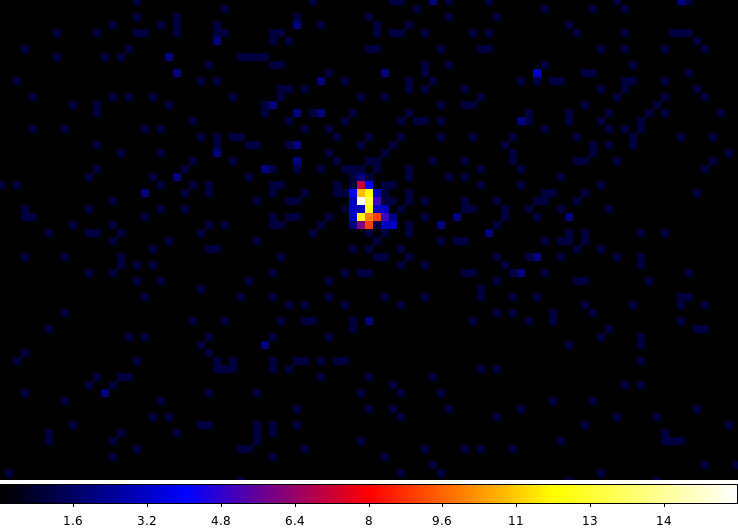

In [6]:
ds9 -cmap b merged1/merged_evt.fits -bin filter 'energy=500:7000' \
  -bin about 3815 3975 -zoom 8 \
  -saveimage png ds9_01.png -quit

display < ds9_01.png

## Merging about specifc ra/dec

In [7]:
/bin/rm -rf merged2
punlearn reproject_obs
reproject_obs 1842,1843 merged2/ refcoord="278.086,-10.58625" cl+

Running reproject_obs
Version: 27 October 2016

Found 1842/repro/acisf01842_repro_evt2.fits
Found 1843/repro/acisf01843_repro_evt2.fits
Verifying 2 observations.
New tangent point: RA=18h 32m 20.64s Dec=-10d 35' 10.5"

Observations to be reprojected:

  Obsid  Obs Date   Exp    DETNAM     SIM_Z    FP   Sepn   PA  
                   (ks)                (mm)    (K)   (')  (deg)
---------------------------------------------------------------
1 1843  2000-09-02   7.9 ACIS-012367 -245.857 153.4   2.4   -67
2 1842  2000-09-02   7.4 ACIS-012367 -231.239 153.4   2.8   +90

Running tasks in parallel with 4 processors.
Reprojecting 2 event files to a common tangent point.
Merging reprojected events files to merged2/merged_evt.fits

The following files were created:

The reprojected event files:
     merged2/1843_reproj_evt.fits
     merged2/1842_reproj_evt.fits

The merged event file:
     merged2/merged_evt.fits

   should not be used to create ARF/RMF/exposure maps because
      the RA_NOM ke

In [8]:
dmhistory merged2/merged_evt.fits reproject_obs 

# dmhistory (CIAO 4.9): WARNING: Found and corrected "pixlib" library parameters

# dmhistory (CIAO 4.9): WARNING: Found and corrected "pixlib" library parameters

# dmhistory (CIAO 4.9): WARNING: Found and corrected "pixlib" library parameters

# dmhistory (CIAO 4.9): WARNING: Found and corrected "pixlib" library parameters

reproject_obs infiles="1842,1843" outroot="merged2/" asolfiles="" merge="yes" refcoord="278.086,-10.58625" parallel="yes" nproc="INDEF" linkfiles="yes" tmpdir="./" clobber="yes" verbose="1" 



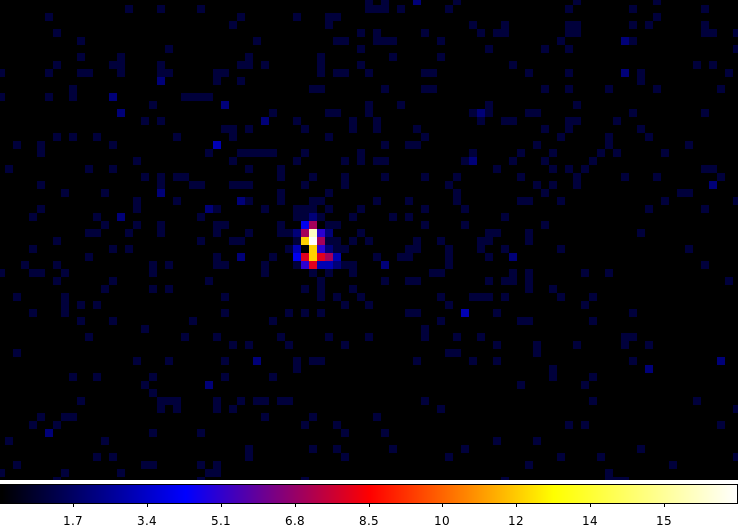

In [9]:
ds9 -cmap b merged2/merged_evt.fits -bin filter 'energy=500:7000' -zoom 8 \
  -saveimage png ds9_02.png -quit

display < ds9_02.png

## Correct aspect

In [10]:
dmstat "1842/repro/acisf01842_repro_evt2.fits[energy=500:7000][sky=circle(4429,4093,5)][cols eqpos]"
p1=`pget dmstat out_mean`
p1x=`stk_read_num ")dmstat.out_mean" 1 echo+`
p1y=`stk_read_num ")dmstat.out_mean" 2 echo+`

EQPOS(RA, DEC)[deg]
    min:	( 278.08616228 -10.587086496 )	      @:	( 63 70 )
    max:	( 278.08718721 -10.58613893 )	      @:	( 34 12 )
   mean:	( 278.08680308 -10.586482825 )
  sigma:	( 0.00023073841914 0.00015688261285 )
    sum:	( 22246.944246 -846.91862601 )
   good:	( 80 80 )
   null:	( 0 0 )



In [11]:
dmstat "1843/repro/acisf01843_repro_evt2.fits[energy=500:7000][sky=circle(3815,3981,5)][cols eqpos]"
p2=`pget dmstat out_mean`
p2x=`stk_read_num ")dmstat.out_mean" 1 echo+`
p2y=`stk_read_num ")dmstat.out_mean" 2 echo+`

EQPOS(RA, DEC)[deg]
    min:	( 278.08649393 -10.586581351 )	      @:	( 14 42 )
    max:	( 278.08732648 -10.585561927 )	      @:	( 26 92 )
   mean:	( 278.08692376 -10.586103961 )
  sigma:	( 0.00014081507536 0.00019400598302 )
    sum:	( 31145.735461 -1185.6436436 )
   good:	( 112 112 )
   null:	( 0 0 )



In [12]:
echo $p1x $p2x
echo $p1y $p2y

278.08680308 278.08692376
-10.586482825 -10.586103961


In [13]:
punlearn wcs_update

cat << EOM > p1.py
import numpy as np
ra1 = $p1x
ra2 = $p2x
dec1 = $p1y
dec2 = $p2y
dra = ra2 - ra1
ddec = dec2 - dec1

mean_dec = ( dec1 + dec2 )/2.0
dra2 = dra * np.cos(mean_dec * np.pi / 180.0)

conv = 0.492 / 3600
dx = dra2 * -1 / conv
dy = ddec / conv

print("dx={} dy={}".format(dx,dy))

from paramio import pset
pset("wcs_update","deltax",str(dx))
pset("wcs_update","deltay",str(dy))
EOM


python p1.py
plist wcs_update



dx=-0.86799472079 dy=2.77217560976

Parameters for /data/sdsreg/thread_output/CIAO4.9/combine/param/wcs_update.par

#
#  wcs_update parameter file
#
        infile =                  Either input asol file, or file with WCS to be updated
       outfile =                  Output asol file
 transformfile =                  Input coordinate transform file
      (wcsfile = )                Input reference WCS file
      (logfile = STDOUT)          debug log file ( STDOUT | stdout | <filename>)
       (deltax = -0.86799472079)  transform delta_x value (sky pixels)
       (deltay = 2.77217560976)   transform delta_y value (sky pixels)
       (rotang = 0)               transform rotation angle (degrees)
     (scalefac = 1)               transform scale factor
      (clobber = no)              Overwrite existing output dataset with same name?
      (verbose = 0)               debug level (0-5)
         (mode = ql)              



In [14]:
pset wcs_update infile=1842/repro/pcadf084280882N003_asol1.fits
pset wcs_update outfile=1842/repro/new_asol1.fits
pset wcs_update wcsfile=1843/repro/acisf01843_repro_evt2.fits
wcs_update mode=h clob+


In [15]:
punlearn reproject_events
pset reproject_events infile=1842/repro/acisf01842_repro_evt2.fits 
pset reproject_events outfile=1842/repro/new_evt2.fits 
pset reproject_events aspect=1842/repro/new_asol1.fits
reproject_events mode=h clob+

In [16]:
dmhedit 1842/repro/new_evt2.fits filelist= op=add key=ASOLFILE value=new_asol1.fits

In [17]:
punlearn reproject_events
reproject_events 1842/repro/new_evt2.fits 1842/repro/reproj_evt2.fits \
  1843/repro/acisf01843_repro_evt2.fits clob+
punlearn dmmerge
dmmerge 1843/repro/acisf01843_repro_evt2.fits,1842/repro/reproj_evt2.fits \
  merged.fits clob+


omit - DEC_PNT values different more than 0.000300
omit - RA_PNT values different more than 0.000300
omit - ROLL_NOM values different more than 1.000000
omit - ROLL_PNT values different more than 1.000000
omit - SIM_Z values different more than 0.100000


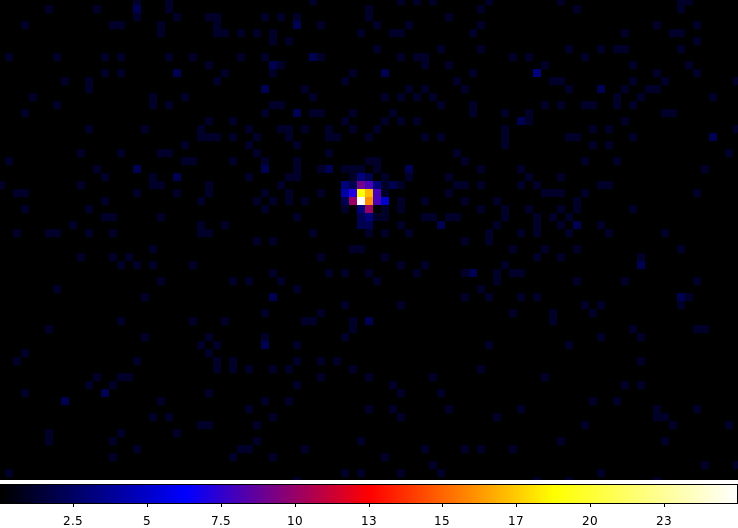

In [18]:
ds9 -cmap b merged.fits -bin filter 'energy=500:7000' \
  -bin about 3815 3975 -zoom 8 \
  -saveimage png ds9_03.png -quit

display < ds9_03.png


## Using reproject obs

In [19]:
punlearn reproject_events
reproject_obs \
  1842/repro/new_evt2.fits,1843/repro/acisf01843_repro_evt2.fits \
  merged3/ clob+


Running reproject_obs
Version: 27 October 2016

Verifying 2 observations.
Calculating new tangent point.
New tangent point: RA=18h 32m 21.696s Dec=-10d 34' 41.484"

Observations to be reprojected:

  Obsid  Obs Date   Exp    DETNAM     SIM_Z    FP   Sepn   PA  
                   (ks)                (mm)    (K)   (')  (deg)
---------------------------------------------------------------
1 1843  2000-09-02   7.9 ACIS-012367 -245.857 153.4   2.6   -79
2 1842  2000-09-02   7.4 ACIS-012367 -231.239 153.4   2.6  +101

Running tasks in parallel with 4 processors.
Reprojecting 2 event files to a common tangent point.
Merging reprojected events files to merged3/merged_evt.fits

The following files were created:

The reprojected event files:
     merged3/1843_reproj_evt.fits
     merged3/1842_reproj_evt.fits

The merged event file:
     merged3/merged_evt.fits

   should not be used to create ARF/RMF/exposure maps because
      the RA_NOM keyword varies by 0.08513503515 (limit is 0.0003)
      

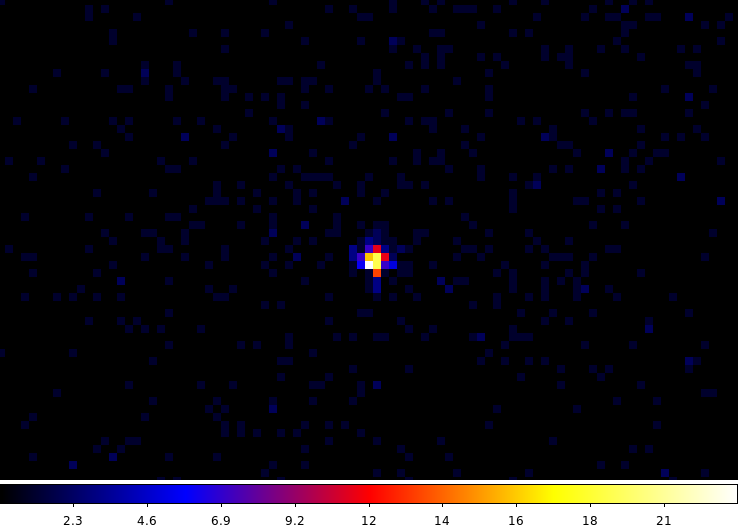

In [20]:
ds9 -cmap b merged3/merged_evt.fits -bin filter 'energy=500:7000' \
  -bin about 4120 4040 -zoom 8 \
  -saveimage png ds9_04.png -quit

display < ds9_04.png